# 12 — IRB Correlation, Conditional PD and Capital K

## From the four inputs to capital K

The four risk components are complete. This notebook applies the Basel correlation relationship and the one-factor Vasicek capital function to each performing loan.

Capital K represents unexpected-loss capital per unit of EAD. Multiplying K by EAD and 12.5 produces IRB RWA.

### The extra terms inside the capital function

| Term | Simple meaning |
|---|---|
| Asset correlation R | the Basel relationship between a borrower or pool and the common systematic risk factor |
| 99.9% conditional PD | default probability conditional on a severe systematic state used by the regulatory formula |
| Capital K | unexpected-loss capital as a fraction of EAD |
| Maturity adjustment | the applicable non-retail adjustment for effective maturity |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from basel_credit_risk.config import load_all_config
from basel_credit_risk.notebook_support import display, ensure_outputs

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
configs = load_all_config(ROOT / "config")
ensure_outputs(ROOT)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)
print(f"Portfolio represented: {len(loans):,} synthetic exposures")

Portfolio represented: 30,000 synthetic exposures


## Correlation treatment by IRB family

Residential mortgage correlation is 15%. Qualifying revolving retail correlation is 4%. Other retail and corporate-family correlations vary with PD. Eligible corporate SMEs also receive the Basel sales-size adjustment.

In [2]:
correlation_reference = pd.DataFrame([
    ["Corporate, bank and sovereign", "PD-dependent function between approximately 12% and 24%", "Maturity adjustment applies"],
    ["Corporate SME", "Corporate PD function less eligible sales-size adjustment", "Maturity adjustment applies"],
    ["Residential mortgage", "15%", "No full maturity adjustment"],
    ["Qualifying revolving retail", "4%", "No full maturity adjustment"],
    ["Other retail", "PD-dependent function between approximately 3% and 16%", "No full maturity adjustment"],
], columns=["IRB family", "Correlation R", "Maturity treatment"])
display(correlation_reference)

,IRB family,Correlation R,Maturity treatment
0,"Corporate, bank and sovereign",PD-dependent function between approximately 12% and 24%,Maturity adjustment applies
1,Corporate SME,Corporate PD function less eligible sales-size adjustment,Maturity adjustment applies
2,Residential mortgage,15%,No full maturity adjustment
3,Qualifying revolving retail,4%,No full maturity adjustment
4,Other retail,PD-dependent function between approximately 3% and 16%,No full maturity adjustment


Correlation is prescribed by the Basel risk function rather than estimated independently for every synthetic loan. Different values explain why two loans with the same PD and LGD can still produce different capital intensity.

## One complete Vasicek calculation

The selected performing corporate loan shows ordinary PD, 99.9% conditional PD, downturn LGD, maturity adjustment and capital K. The conditional PD is a regulatory tail-state calculation, not a forecast that this borrower will default with that probability.

In [3]:
vasicek_example = loans.loc[
    loans["irb_function"].eq("corporate") & loans["default_flag"].eq(0)
].iloc[0]
base_unexpected_loss = vasicek_example["lgd_regulatory"] * (
    vasicek_example["conditional_pd_999"] - vasicek_example["pd_regulatory"]
)
manual_k = max(base_unexpected_loss * vasicek_example["maturity_adjustment"], 0)

display(pd.Series({
    "PD": vasicek_example["pd_regulatory"],
    "Downturn LGD": vasicek_example["lgd_regulatory"],
    "Correlation R": vasicek_example["asset_correlation_r"],
    "99.9% conditional PD": vasicek_example["conditional_pd_999"],
    "LGD × (conditional PD − PD)": base_unexpected_loss,
    "Maturity adjustment": vasicek_example["maturity_adjustment"],
    "Capital K": vasicek_example["capital_k"],
}).to_frame("Value"))
assert np.isclose(manual_k, vasicek_example["capital_k"])

,Value
PD,0.000500
Downturn LGD,0.743761
Correlation R,0.237037
99.9% conditional PD,0.020442
LGD × (conditional PD − PD),0.014832
Maturity adjustment,2.839561
Capital K,0.042117


If conditional PD were 15%, ordinary PD 2% and LGD 40%, the pre-maturity result would be `40% × (15% − 2%) = 5.2%`. Corporate K can then change through the maturity adjustment. Retail K uses its relevant correlation but no full maturity adjustment.

## Loan-level capital intensity

Each point is a performing loan. The horizontal axis is PD and the vertical axis is K. Colour represents the final LGD used, including supervisory treatment where applicable. The plotted sample is capped at 4,000 performing loans. Capital is nonlinear rather than a fixed multiple of PD.

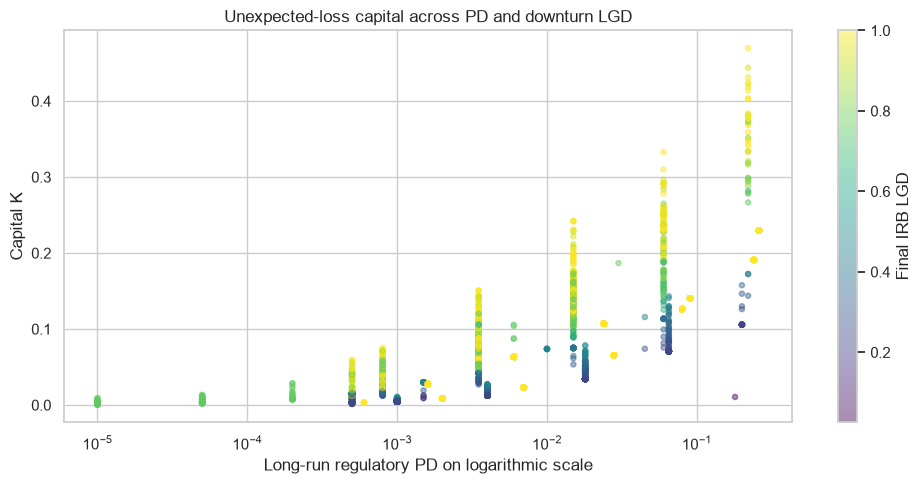

In [4]:
plot_sample = loans.loc[loans["default_flag"].eq(0)].sample(min(4000, int(loans["default_flag"].eq(0).sum())), random_state=42)
plt.figure(figsize=(10, 5))
points = plt.scatter(plot_sample["pd_regulatory"], plot_sample["capital_k"], c=plot_sample["lgd_regulatory"], s=14, alpha=0.45, cmap="viridis")
plt.xscale("log")
plt.xlabel("Long-run regulatory PD on logarithmic scale")
plt.ylabel("Capital K")
plt.title("Unexpected-loss capital across PD and downturn LGD")
plt.colorbar(points, label="Final IRB LGD")
plt.tight_layout()
plt.show()

Higher PD and LGD generally move points upward, but correlation and maturity also matter. K is the risk intensity carried into the loan-level IRB RWA calculation next.